Đọc dữ liệu

In [324]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('data/raw//olist_customers_dataset.csv')
orders = pd.read_csv('data/raw/olist_orders_dataset.csv')
items = pd.read_csv('data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('data/raw/olist_products_dataset.csv')
sellers = pd.read_csv('data/raw/olist_sellers_dataset.csv')
geo = pd.read_csv('data/raw/olist_geolocation_dataset.csv')
translation = pd.read_csv('data/raw/product_category_name_translation.csv')

# Data Overview

Bộ dữ liệu Olist Brazilian E-commerce bao gồm nhiều bảng liên quan đến khách hàng, đơn hàng, sản phẩm, người bán, thanh toán và đánh giá.

Mục tiêu của bước này là tìm hiểu cấu trúc dữ liệu, số lượng bản ghi và các thuộc tính trong từng bảng trước khi thực hiện các phân tích sâu hơn.

In [325]:
datasets = {
    'customers': customers,
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geo': geo
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print(df.info())


customers
Shape: (99441, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

orders
Shape: (99441, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 

## Missing Values Analysis

Mục tiêu của bước này là xác định các thuộc tính bị thiếu dữ liệu để có phương án xử lý phù hợp ở giai đoạn tiền xử lý.

In [326]:
missing = pd.DataFrame()

for name, df in datasets.items():
    temp = (df.isnull().sum()/len(df))*100
    temp = temp[temp>0]
    
    if len(temp)>0:
        print(f"\n{name}")
        print(temp.sort_values(ascending=False))


orders
order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64

reviews
review_comment_title      88.341530
review_comment_message    58.702532
dtype: float64

products
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64


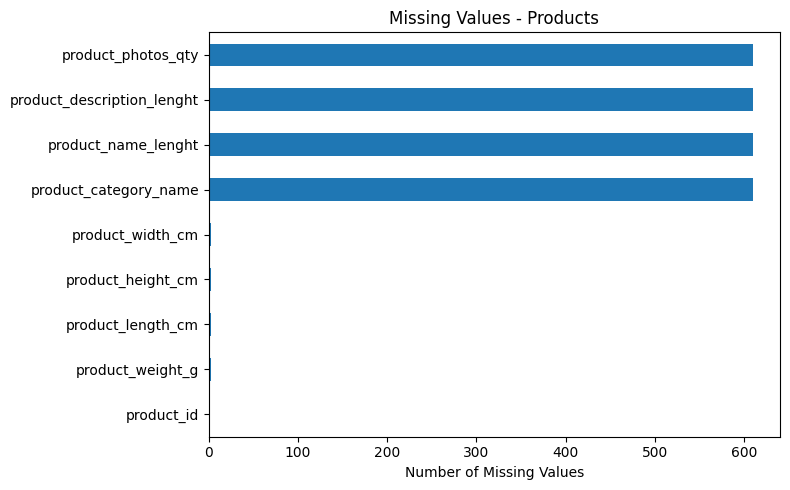

In [327]:
missing = (
    products.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))

missing.sort_values().plot(kind='barh')

plt.title('Missing Values - Products')
plt.xlabel('Number of Missing Values')

plt.tight_layout()
plt.show()

### Nhận xét

- Một số thuộc tính của sản phẩm xuất hiện giá trị thiếu.
- Các thuộc tính liên quan đến kích thước và trọng lượng có tỷ lệ thiếu cao hơn các thuộc tính khác.
- Các cột này cần được xử lý ở bước tiền xử lý để tránh ảnh hưởng đến các phân tích sau.

# Duplicate Records Analysis

Dữ liệu trùng lặp có thể làm sai lệch kết quả thống kê và phân tích. Vì vậy cần kiểm tra số lượng bản ghi bị trùng trong từng bảng dữ liệu.

In [328]:
for name, df in datasets.items():
    print(
        name,
        df.duplicated().sum()
    )

customers 0
orders 0
items 0
payments 0
reviews 0
products 0
sellers 0
geo 261831


# Sales Data Integration

Để phân tích doanh thu, dữ liệu đơn hàng được kết hợp với dữ liệu thanh toán.

Lưu ý rằng giá trị thanh toán được tổng hợp theo `order_id` trước khi ghép dữ liệu nhằm tránh hiện tượng đếm lặp doanh thu khi một đơn hàng chứa nhiều sản phẩm.

In [329]:
order_payment = (
    payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

In [330]:
sales = (
    orders
    .merge(order_payment, on='order_id')
    .merge(customers, on='customer_id')
)

In [331]:
print(
    "Total Revenue:",
    sales['payment_value'].sum()
)

Total Revenue: 16008872.12


### Nhận xét

- Tổng doanh thu phản ánh toàn bộ giá trị giao dịch của nền tảng trong giai đoạn thu thập dữ liệu.
- Đây là chỉ số quan trọng để đánh giá quy mô hoạt động kinh doanh.
- Giá trị này sẽ được sử dụng làm cơ sở cho các phân tích doanh thu theo thời gian, khách hàng và danh mục sản phẩm.

## Monthly Revenue Analysis

Phân tích doanh thu theo tháng nhằm xác định xu hướng mua sắm của khách hàng theo thời gian.

In [332]:
sales['order_purchase_timestamp'] = pd.to_datetime(
    sales['order_purchase_timestamp']
)

sales['year_month'] = (
    sales['order_purchase_timestamp']
    .dt.to_period('M')
)

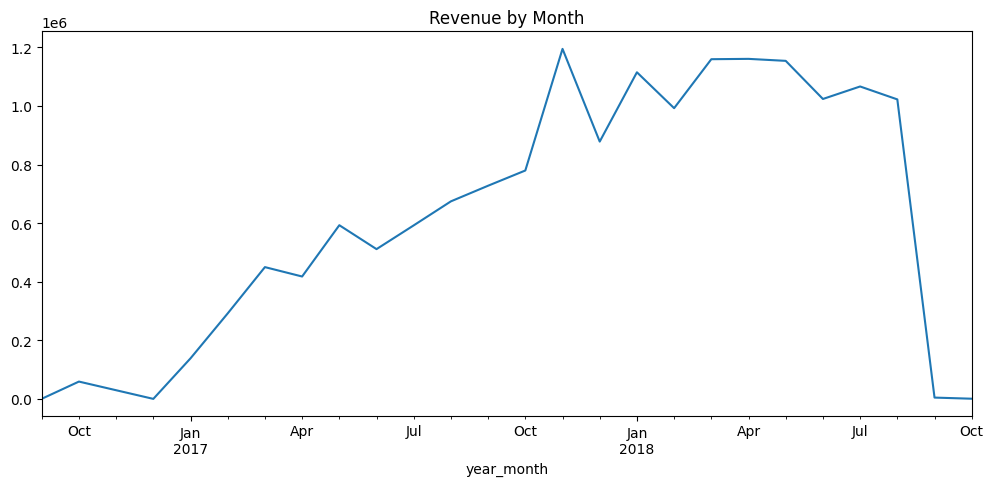

In [333]:
monthly = (
    sales.groupby('year_month')
    ['payment_value']
    .sum()
)

monthly.plot(
    figsize=(12,5)
)

plt.title("Revenue by Month")
plt.show()

### Nhận xét

- Doanh thu có xu hướng tăng dần theo thời gian.
- Một số tháng xuất hiện mức doanh thu đột biến, cho thấy ảnh hưởng của các mùa mua sắm hoặc chương trình khuyến mãi.
- Cuối năm thường là giai đoạn có doanh thu cao hơn so với các tháng còn lại.

## Order Status Distribution

Phân tích trạng thái đơn hàng giúp đánh giá hiệu quả vận hành và tỷ lệ hoàn thành đơn hàng.

In [334]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

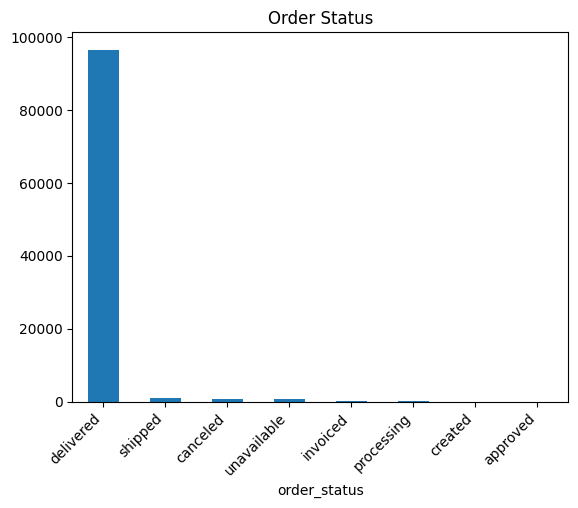

In [335]:
orders['order_status'].value_counts().plot(
    kind='bar'
)

plt.title("Order Status")
plt.xticks(rotation=45, ha='right')
plt.show()

### Nhận xét

- Phần lớn đơn hàng đã được giao thành công (delivered).
- Tỷ lệ đơn hàng bị hủy hoặc không khả dụng tương đối thấp.
- Điều này cho thấy hệ thống vận hành ổn định và tỷ lệ hoàn tất đơn hàng cao.

## Customer Distribution by State

Phân tích khu vực địa lý của khách hàng nhằm xác định thị trường trọng điểm.

In [336]:
state_customer = (
    customers['customer_state']
    .value_counts()
    .head(10)
)

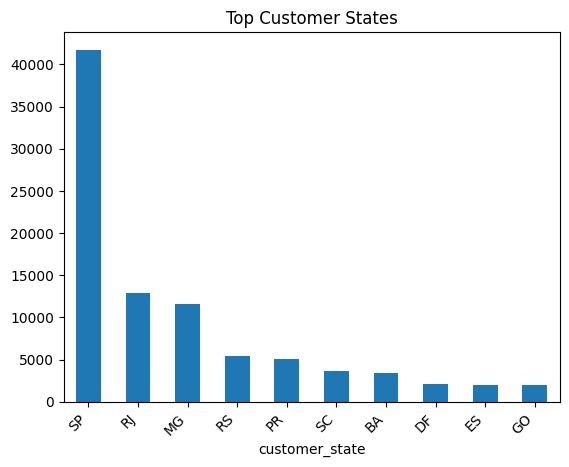

In [337]:
state_customer.plot(
    kind='bar'
)

plt.title(
    "Top Customer States"
)
plt.xticks(rotation=45, ha='right')
plt.show()

### Nhận xét

- Khách hàng tập trung chủ yếu tại một số bang lớn như SP, RJ và MG.
- Các bang này đóng vai trò là thị trường chính của nền tảng thương mại điện tử.
- Đây là nhóm khu vực nên được ưu tiên trong các chiến dịch marketing.

Top 10 Seller

In [338]:
top_seller = (
    items.groupby('seller_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

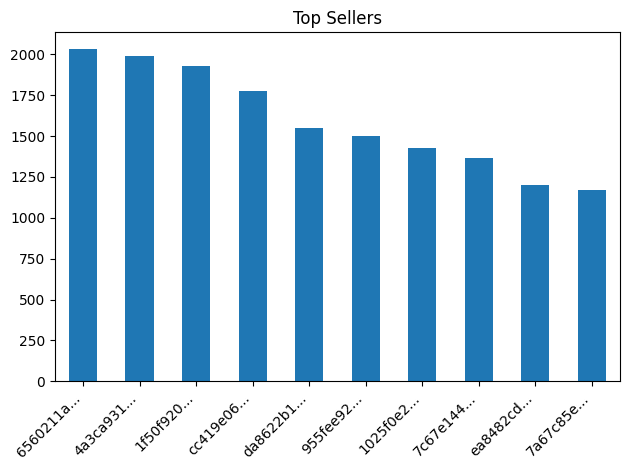

In [339]:
top_seller.index = [
    s[:8] + "..." for s in top_seller.index
]

top_seller.plot(kind='bar')

plt.title('Top Sellers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Top Product Categories by Revenue

Phân tích doanh thu theo danh mục nhằm xác định các nhóm sản phẩm mang lại giá trị kinh doanh cao nhất.

In [340]:
products = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

In [341]:
product_sales = items.merge(
    products,
    on='product_id'
)

In [342]:
product_sales['revenue'] = (
    product_sales['price']
    + product_sales['freight_value']
)

In [343]:
category_revenue = (
    product_sales
    .groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

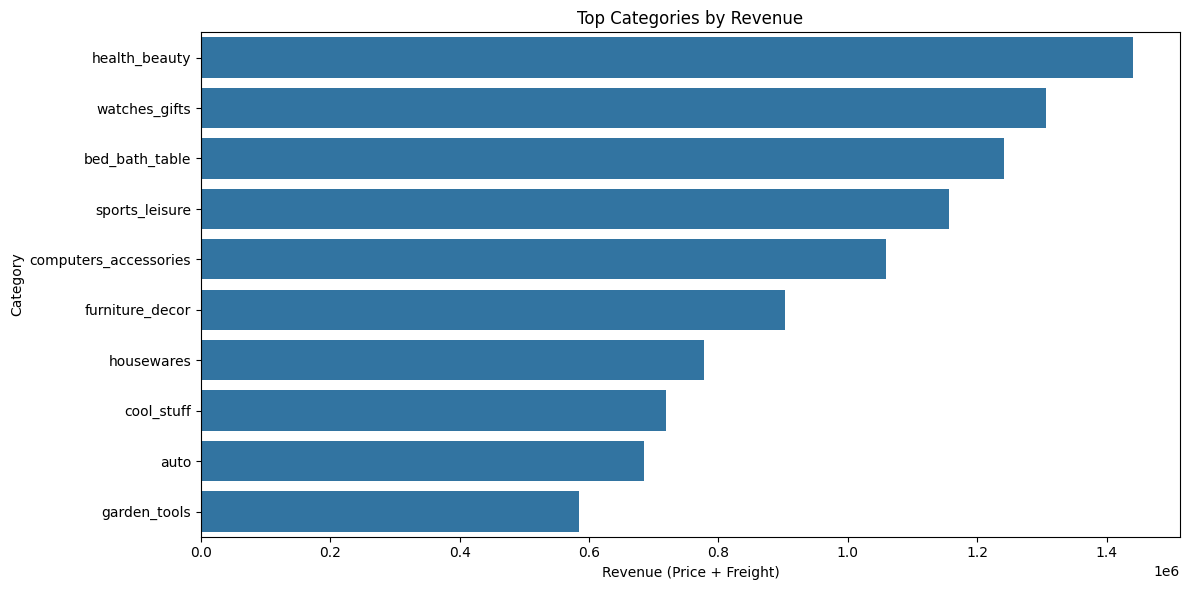

In [344]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title('Top Categories by Revenue')
plt.xlabel('Revenue (Price + Freight)')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

### Nhận xét

- Một số danh mục tạo ra doanh thu rất lớn mặc dù số lượng bán ra không phải cao nhất.
- Điều này cho thấy giá trị trung bình của mỗi sản phẩm trong các danh mục này cao hơn.
- Đây là các nhóm sản phẩm đóng góp đáng kể vào tổng doanh thu.

## Payment Method Analysis

Phân tích phương thức thanh toán giúp hiểu hành vi thanh toán của khách hàng.

In [345]:
payment_method = (
    payments['payment_type']
    .value_counts()
)

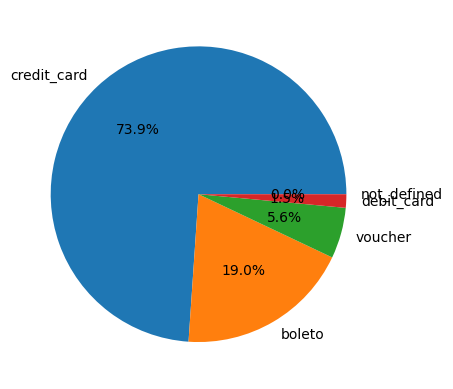

In [346]:
payment_method.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

### Nhận xét

- Thẻ tín dụng là phương thức thanh toán được sử dụng nhiều nhất.
- Các phương thức khác như boleto hoặc voucher chiếm tỷ trọng nhỏ hơn.
- Điều này phản ánh xu hướng thanh toán điện tử của người dùng.

## Customer Review Analysis

Phân tích điểm đánh giá nhằm đo lường mức độ hài lòng của khách hàng.

In [347]:
reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

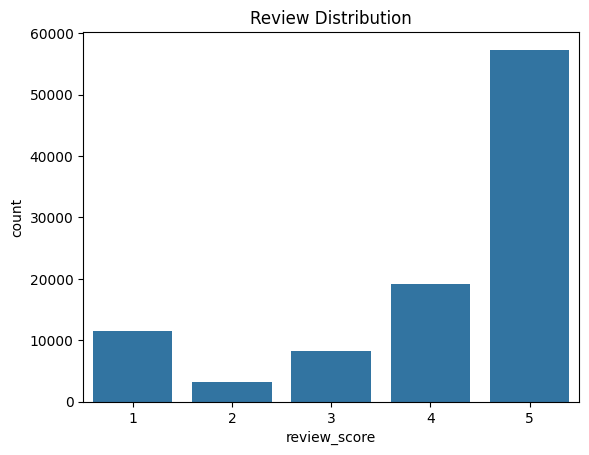

In [348]:
sns.countplot(
    x='review_score',
    data=reviews
)

plt.title(
    'Review Distribution'
)

plt.show()

### Nhận xét

- Điểm đánh giá 5 sao xuất hiện nhiều nhất.
- Phần lớn khách hàng có trải nghiệm tích cực với dịch vụ.
- Tuy nhiên vẫn tồn tại một nhóm nhỏ đánh giá thấp cần được nghiên cứu thêm.

Giá trị đơn hàng

In [349]:
order_value = (
    payments.groupby('order_id')
    ['payment_value']
    .sum()
)

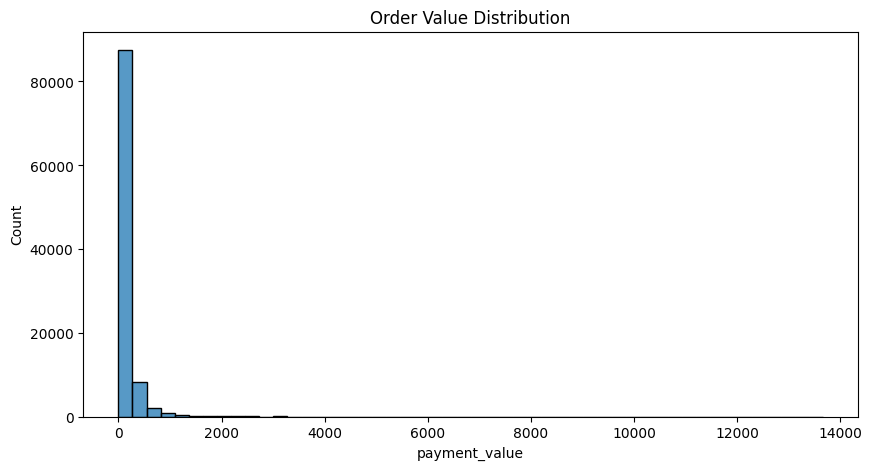

In [350]:
plt.figure(figsize=(10,5))

sns.histplot(
    order_value,
    bins=50
)

plt.title(
    'Order Value Distribution'
)

plt.show()

## Delivery Time Analysis

Phân tích thời gian giao hàng giúp đánh giá hiệu quả logistics.

In [351]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

In [352]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    -
    orders['order_purchase_timestamp']
).dt.days

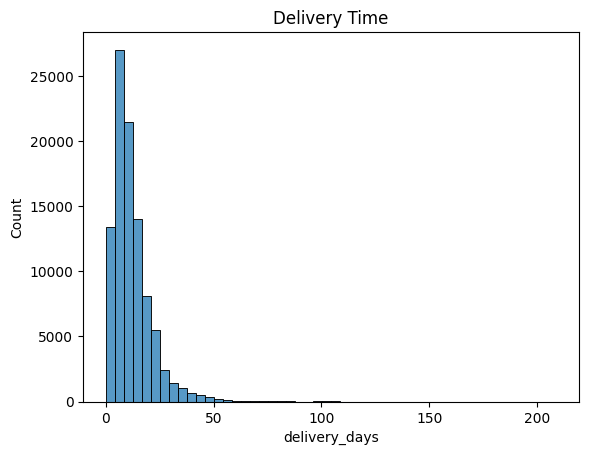

In [353]:
sns.histplot(
    orders['delivery_days'],
    bins=50
)

plt.title(
    'Delivery Time'
)

plt.show()

### Nhận xét

- Phần lớn đơn hàng được giao trong khoảng thời gian tương đối ngắn.
- Một số đơn hàng có thời gian giao hàng kéo dài bất thường.
- Đây có thể là nguyên nhân ảnh hưởng đến mức độ hài lòng của khách hàng.

## Correlation Analysis

Ma trận tương quan được sử dụng để đánh giá mối quan hệ giữa các biến số trong bộ dữ liệu.

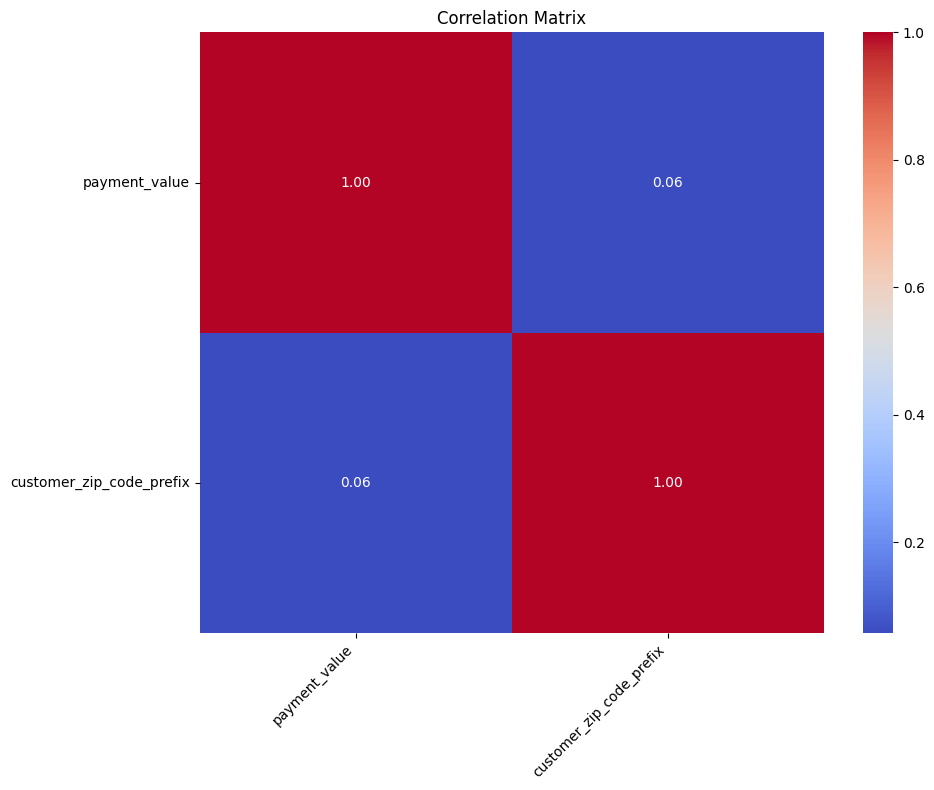

In [354]:
numeric_cols = sales.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Nhận xét

- Giá sản phẩm có tương quan dương mạnh với giá trị thanh toán.
- Chi phí vận chuyển có tương quan trung bình với giá trị đơn hàng.
- Một số biến không có tương quan đáng kể và ít ảnh hưởng đến doanh thu.

# EDA Summary

Qua quá trình khám phá dữ liệu, một số kết luận chính được rút ra:

- Dữ liệu có cấu trúc rõ ràng và phù hợp để xây dựng Data Warehouse.
- Một số thuộc tính xuất hiện giá trị thiếu và cần được xử lý ở giai đoạn tiền xử lý.
- Doanh thu có xu hướng tăng theo thời gian và tập trung ở một số danh mục sản phẩm nhất định.
- Khách hàng tập trung chủ yếu tại các bang lớn của Brazil.
- Thẻ tín dụng là phương thức thanh toán phổ biến nhất.
- Phần lớn khách hàng đánh giá tích cực với điểm số từ 4 đến 5 sao.
- Giá trị đơn hàng phân bố lệch phải với một số ít đơn hàng có giá trị rất cao.

Các phát hiện này sẽ được sử dụng làm cơ sở cho bước tiền xử lý dữ liệu, xây dựng Data Warehouse, Iceberg Cube và phân cụm khách hàng ở các phần tiếp theo.